In [1]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ajos = pd.read_csv("data/ajos.csv", names=["Cultivar", "Rendimiento"])

In [5]:
orden = ajos.groupby('Cultivar')['Rendimiento'].mean().sort_values()

/tmp/ipykernel_28237/868300759.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


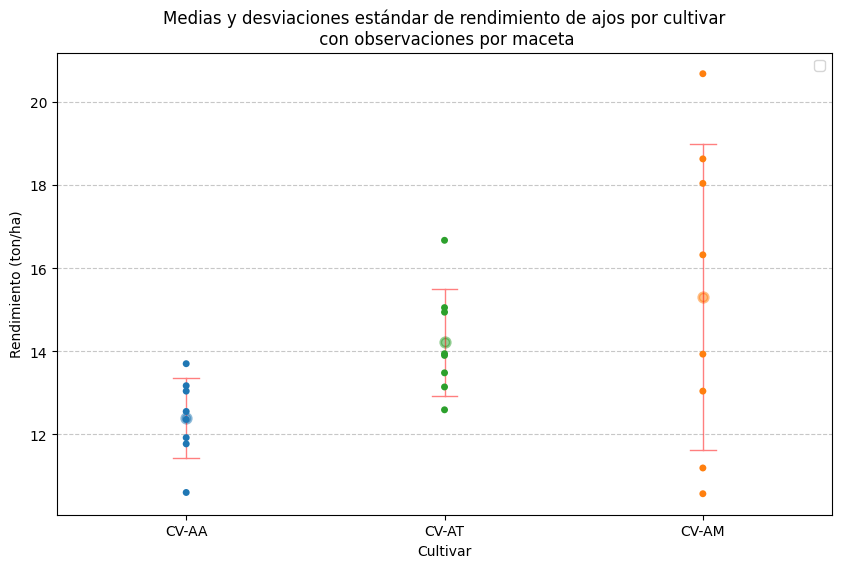

In [7]:
plt.figure(figsize=(10,6))
sns.pointplot(data=ajos, 
              x="Cultivar", 
              y="Rendimiento", 
              hue="Cultivar",
              errorbar="sd", 
              estimator="mean",
              linestyles="none", 
              order=orden.index,
              alpha=0.5,
              capsize=0.1,
              err_kws={"linewidth":1, "color":"red"})
sns.stripplot(data=ajos, 
                x="Cultivar", 
                y="Rendimiento",
                hue="Cultivar",
                order=orden.index,
                jitter=False)
plt.title("Medias y desviaciones estándar de rendimiento de ajos por cultivar\n con observaciones por maceta")
plt.xlabel("Cultivar")
plt.ylabel("Rendimiento (ton/ha)")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
ajos_lm = ols('Rendimiento ~ Cultivar', data=ajos).fit()
ajos_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Rendimiento   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.161
Method:                 Least Squares   F-statistic:                     3.213
Date:                Fri, 25 Sep 2026   Prob (F-statistic):             0.0606
Time:                        07:47:23   Log-Likelihood:                -52.665
No. Observations:                  24   AIC:                             111.3
Df Residuals:                      21   BIC:                             114.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            12.3888      0.821     15.094      0.000      10.682      14.096
Cultivar[T.CV-AM]     2.9112      1.161      2.508      0.020       0.497       5.325
Cultivar[T.CV-AT]     1.8250      1.161      1.572      0.131      -0.589       4.239
==============================================================================
Omnibus:                        1.440   Durbin-Watson:                   2.215
Prob(Omnibus):                  0.487   Jarque-Bera (JB):                0.366
Skew:                           0.129   Prob(JB):                        0.833
Kurtosis:                       3.548   Cond. No.                         3.73
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
sm.stats.anova_lm(ajos_lm, typ=2)

,sum_sq,df,F,PR(>F)
Cultivar,34.629175,2.0,3.212783,0.060627
Residual,113.174875,21.0,NaN,NaN
